# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('cleaned_aviation_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70545 entries, 0 to 70544
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                70545 non-null  object 
 1   Event.Date              70545 non-null  object 
 2   Make                    70545 non-null  object 
 3   Model                   70545 non-null  object 
 4   Aircraft.damage         70545 non-null  object 
 5   Injury.Severity         70545 non-null  object 
 6   Total.Fatal.Injuries    70545 non-null  float64
 7   Total.Serious.Injuries  70545 non-null  float64
 8   Total.Minor.Injuries    70545 non-null  float64
 9   Total.Uninjured         70545 non-null  float64
 10  Number.of.Engines       70545 non-null  float64
 11  Engine.Type             70545 non-null  object 
 12  Weather.Condition       70545 non-null  object 
 13  Broad.phase.of.flight   70545 non-null  object 
 14  Purpose.of.flight       70545 non-null

In [23]:
df['Make'].unique()


array(['CESSNA', 'PIPER', 'BALLOON WORKS', 'NORTH AMERICAN', 'BEECH',
       'SWEARINGEN', 'CANADAIR', 'DOUGLAS', 'MOONEY', 'BELL', 'SCHWEIZER',
       'BOEING', 'HILLER', 'BELLANCA', 'ROBINSON', 'GRUMMAN', 'LUSCOMBE',
       'ENSTROM', 'MCDONNELL DOUGLAS', 'LOCKHEED', 'CHAMPION', 'MAULE',
       'AERO COMMANDER', 'MITSUBISHI', 'STINSON', 'AEROSTAR', 'LEARJET',
       'ROCKWELL', 'TAYLORCRAFT', 'GULFSTREAM', 'EMBRAER', 'AERONCA',
       'NAVION', 'AEROSPATIALE', 'HELIO', 'DE HAVILLAND', 'HUGHES',
       'AYRES', 'RAVEN', 'RYAN', 'BURKHART GROB', 'AMERICAN',
       'AIR TRACTOR', 'LET', 'ERCOUPE', 'GREAT LAKES', 'WEATHERLY',
       'GLOBE', 'SCHEMPP-HIRTH', 'WACO', 'SCHLEICHER', 'LAKE', 'PITTS',
       'MBB', 'SIKORSKY', 'FAIRCHILD', 'WSK PZL MIELEC', 'PILATUS',
       'AIRBUS', 'CAMERON', 'FOKKER', 'BRITISH AEROSPACE', 'AGUSTA',
       'CIRRUS', 'SOCATA', 'AVIAT', 'EUROCOPTER', 'BOMBARDIER',
       'RAYTHEON AIRCRAFT COMPANY', 'AMERICAN CHAMPION', 'FLIGHT DESIGN',
       'DIAMOND'], dt

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:
# aircraft_size column (Large if occupants >= 20, else Small)
df["Aircraft_Size"] = np.where(df["Total_Occupants"] >= 20, "LARGE", "SMALL")
df["Aircraft_Size"].value_counts()

Aircraft_Size
SMALL    67982
LARGE     2563
Name: count, dtype: int64

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [5]:
df['Fatal_Serious_Fraction'] = (df['Total.Serious.Injuries'] + df['Total.Fatal.Injuries'])/df['Total_Occupants']

In [6]:
size_stats_df = df.groupby(['Aircraft_Size', 'Make'])['Fatal_Serious_Fraction'].mean()
size_stats_df.sort_values().head(15)

Aircraft_Size  Make             
LARGE          AERO COMMANDER       0.000000
               SWEARINGEN           0.000000
               MOONEY               0.000000
               HUGHES               0.000000
               GULFSTREAM           0.000000
               SIKORSKY             0.000000
               CANADAIR             0.017705
               AEROSPATIALE         0.035119
               MCDONNELL DOUGLAS    0.036424
               LEARJET              0.043478
               BOMBARDIER           0.043844
               BOEING               0.057580
               AIRBUS               0.066849
               CESSNA               0.069383
               EMBRAER              0.072220
Name: Fatal_Serious_Fraction, dtype: float64

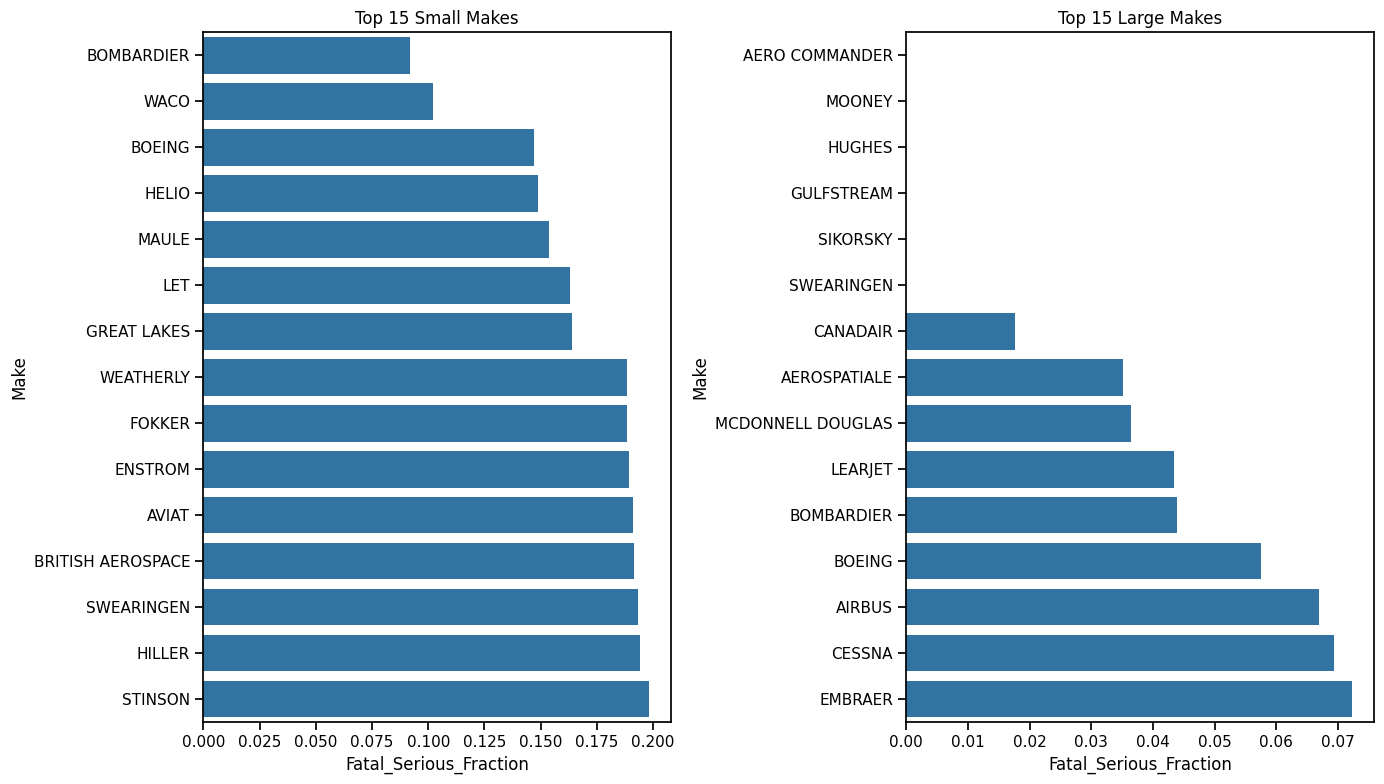

In [7]:

#group by make and size, then mean of fatal/serious injuries fraction
make_stats = (
    df.groupby(['Aircraft_Size', 'Make'])["Fatal_Serious_Fraction"].mean().reset_index()
)
low_risk_small = (
    make_stats[make_stats['Aircraft_Size'] == 'SMALL']
    .sort_values(by='Fatal_Serious_Fraction')
    .head(15)
)
low_risk_large = (
    make_stats[make_stats['Aircraft_Size'] == 'LARGE']
    .sort_values(by='Fatal_Serious_Fraction')
    .head(15))


sns.set_context("notebook")


fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# 3. Plot Small Makes (Left Plot - axes[0])
sns.barplot(
    data=low_risk_small,
    x="Fatal_Serious_Fraction",
    y="Make",
    ax=axes[0]
    
)
axes[0].set_title("Top 15 Small Makes")

# 4. Plot Large Makes (Right Plot - axes[1])
sns.barplot(
    data=low_risk_large,
    x="Fatal_Serious_Fraction",
    y="Make",
    ax=axes[1]
)
axes[1].set_title("Top 15 Large Makes")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [8]:
# Convert MultiIndex to columns
size_stats_df = size_stats_df.reset_index()

# Now filter normally
small = size_stats_df[size_stats_df["Aircraft_Size"] == "SMALL"]
small_stats = small.sort_values(by='Fatal_Serious_Fraction')
data = small_stats.head(10)

#sns.violinplot(data=data, x='Fatal_Serious_Fraction', y='Make')
#plt.title("Mean of serious fatal injuries by Make for small planes(10 lowest)")
data

,Aircraft_Size,Make,Fatal_Serious_Fraction
43,SMALL,BOMBARDIER,0.091923
96,SMALL,WACO,0.101918
42,SMALL,BOEING,0.146961
65,SMALL,HELIO,0.148728
73,SMALL,MAULE,0.153889
70,SMALL,LET,0.162963
62,SMALL,GREAT LAKES,0.163793
97,SMALL,WEATHERLY,0.188235
60,SMALL,FOKKER,0.188312
55,SMALL,ENSTROM,0.189286


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

Text(0.5, 1.0, 'Mean of serious fatal injuries by Make for large planes(10 lowest)')

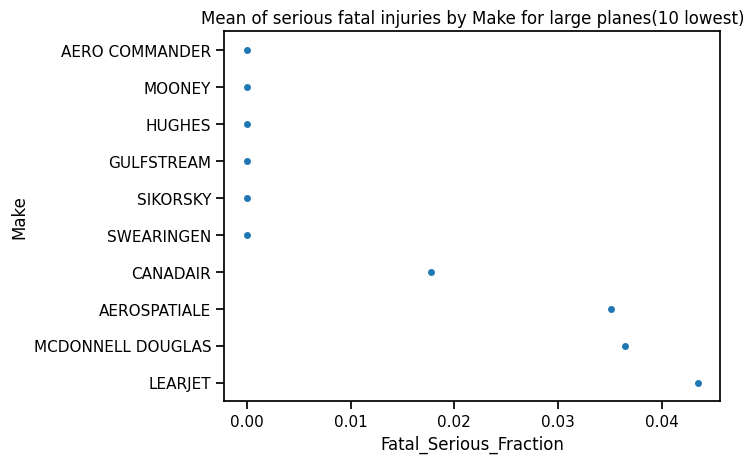

In [9]:
# Convert MultiIndex to columns
#size_stats_df = size_stats_df.reset_index()

# Now filter normally
large = size_stats_df[size_stats_df["Aircraft_Size"] == "LARGE"]
large_stats = large.sort_values(by='Fatal_Serious_Fraction')
large_data = large_stats.head(10)

sns.stripplot(data=large_data, y='Make', x='Fatal_Serious_Fraction')
plt.title("Mean of serious fatal injuries by Make for large planes(10 lowest)")
#large_data

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [10]:
planes_destruction = df.groupby(['Aircraft_Size', 'Make'])['Is_Destroyed'].mean().reset_index()
large_planes_destruction = planes_destruction[planes_destruction['Aircraft_Size']=='LARGE']
large_planes_destruction.sort_values(by='Is_Destroyed').head(15)

,Aircraft_Size,Make,Is_Destroyed
0,LARGE,AERO COMMANDER,0.000000
24,LARGE,RAYTHEON AIRCRAFT COMPANY,0.000000
22,LARGE,MOONEY,0.000000
18,LARGE,HUGHES,0.000000
17,LARGE,GULFSTREAM,0.000000
25,LARGE,SIKORSKY,0.000000
8,LARGE,CAMERON,0.000000
26,LARGE,SWEARINGEN,0.000000
1,LARGE,AEROSPATIALE,0.029412
6,LARGE,BOMBARDIER,0.035714


In [11]:
planes_destruction = df.groupby(['Aircraft_Size', 'Make'])['Is_Destroyed'].mean().reset_index()
small_planes_destruction = planes_destruction[planes_destruction['Aircraft_Size']=='SMALL']
small_planes_destruction.sort_values(by='Is_Destroyed').head(15)

,Aircraft_Size,Make,Is_Destroyed
33,SMALL,AIRBUS,0.033333
43,SMALL,BOMBARDIER,0.033333
35,SMALL,AMERICAN CHAMPION,0.037037
52,SMALL,DIAMOND,0.056911
42,SMALL,BOEING,0.061491
83,SMALL,RAVEN,0.063291
38,SMALL,BALLOON WORKS,0.064748
36,SMALL,AVIAT,0.069124
59,SMALL,FLIGHT DESIGN,0.075949
70,SMALL,LET,0.081481


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

#### fatal injury rate
* Generally, we can conclude that fatal or serious injury rate in large plane makes in lower than in small plane makes, given that in the top 10 for each group, the fraction of fatally/seriously injured in large plane makes 8 out of 10 have zero rates compared to small plane makes which the lowest fraction of fatal/seriously injured is  about 0.08.
#### destruction rate
* Just as for the fatal/serious injury rate, the smaller planes are easily destroyed in the cause of an incident compared to large plane makes, that might explain why smaller planes have higher fraction of fatal/ serious injuries rate.
#### Potential recommendation
* Large - AERO COMMANDER, MOONEY, HUGHES, GULFSTREAM, GATES LEARJET, SIKORSKY,DEHAVILLAND - Has both 0 rates of fatal/serious injuries and 0 destruction rate.
* Small - BOMBARDIER(0.088 fraction of fatal/serious injury and about 0.026 rate of total destruction,) BOMBARDIER INC,

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Text(0.5, 1.0, 'Mean of serious/fatal injuries for large plane types(make-model)')

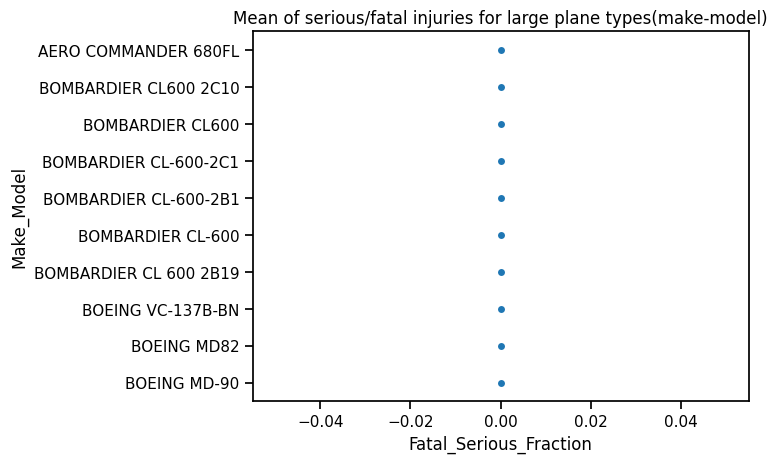

In [12]:
make_model_stats = df.groupby(['Aircraft_Size', 'Make_Model'])['Fatal_Serious_Fraction'].mean().reset_index()
make_model_stats

large_planes = make_model_stats[make_model_stats["Aircraft_Size"] == "LARGE"]
large_planes = large_planes.sort_values(by='Fatal_Serious_Fraction')
large_make_model = large_planes.head(10)
#large_make_model

sns.stripplot(data=large_make_model, x='Fatal_Serious_Fraction', y='Make_Model')
plt.title("Mean of serious/fatal injuries for large plane types(make-model)")

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Text(0.5, 1.0, 'Mean of serious/ fatal injuries for small plane types(make-model)')

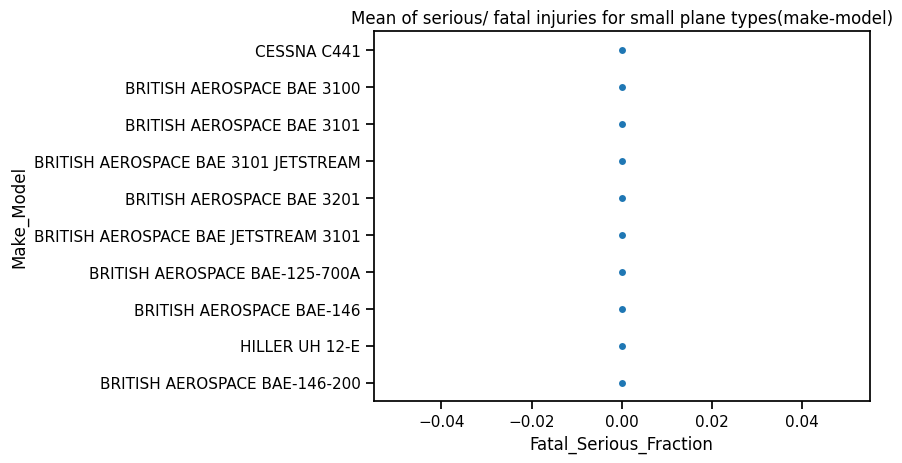

In [13]:
make_model_stats = df.groupby(['Aircraft_Size', 'Make_Model'])['Fatal_Serious_Fraction'].mean().reset_index()
make_model_stats

small_planes = make_model_stats[make_model_stats["Aircraft_Size"] == "SMALL"]
small_planes = small_planes.sort_values(by='Fatal_Serious_Fraction')
small_make_model = small_planes.head(10)
#small_make_model

sns.stripplot(data=small_make_model, x='Fatal_Serious_Fraction', y='Make_Model')
plt.title("Mean of serious/ fatal injuries for small plane types(make-model)")

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [14]:
df.groupby(['Weather.Condition', 'Aircraft.damage'])['Fatal_Serious_Fraction'].mean()

Weather.Condition  Aircraft.damage
IMC                DESTROYED          0.926828
                   MINOR              0.035730
                   SUBSTANTIAL        0.307313
                   UNKNOWN            0.047886
UNKNOWN            DESTROYED          0.890708
                   MINOR              0.013873
                   SUBSTANTIAL        0.412808
                   UNKNOWN            0.165959
VMC                DESTROYED          0.703347
                   MINOR              0.052220
                   SUBSTANTIAL        0.130166
                   UNKNOWN            0.119480
Name: Fatal_Serious_Fraction, dtype: float64

In [15]:
engine_effect = df.groupby(['Engine.Type', 'Aircraft.damage'])['Fatal_Serious_Fraction'].mean().reset_index()
#engine_effect.sort_values(by=['Number.of.Engines','Fatal_Serious_Fraction'])
engine_effect

,Engine.Type,Aircraft.damage,Fatal_Serious_Fraction
0,GEARED TURBOFAN,MINOR,0.000000
1,GEARED TURBOFAN,UNKNOWN,NaN
2,RECIPROCATING,DESTROYED,0.754064
3,RECIPROCATING,MINOR,0.073780
4,RECIPROCATING,SUBSTANTIAL,0.132651
5,RECIPROCATING,UNKNOWN,0.313923
6,TURBO FAN,DESTROYED,0.746158
7,TURBO FAN,MINOR,0.006411
8,TURBO FAN,SUBSTANTIAL,0.042278
9,TURBO FAN,UNKNOWN,0.015727
